# 01 — Data Lineage & Data Warehouse




# Part 1: Concept ทั่วไป

## 1.1 Data Platform คืออะไร

Data Platform คือระบบหรือชุดเครื่องมือที่ช่วยให้องค์กรจัดการข้อมูลตั้งแต่การเก็บ นำเข้า แปลง วิเคราะห์ ไปจนถึงควบคุมคุณภาพและ governance ของข้อมูล เพื่อให้ข้อมูลพร้อมใช้งานสำหรับ BI, Analytics, Data Science และ AI

ใน modern data stack มี 5 layers
1. **Data Storage & Processing** — เก็บและประมวลผลข้อมูล
2. **Data Ingestion** — นำข้อมูลจาก source เข้ามา
3. **Data Transformation** — clean และ transform ให้พร้อมใช้
4. **BI & Analytics** — วิเคราะห์และทำ dashboard/report
5. **Data Observability** — ติดตามคุณภาพและความพร้อมของข้อมูล

## 1.2 Data Warehouse vs Data Lake vs Data Mart

| | Data Lake | Data Warehouse | Data Mart |
|---|---|---|---|
| **จุดประสงค์** | เก็บ raw data หลายรูปแบบ | เก็บข้อมูลที่ clean แล้วเพื่อ analytics | เก็บข้อมูลเฉพาะทีม |
| **ข้อมูล** | Raw / structured / semi / unstructured | Structured / processed | Focused dataset |
| **Process** | ELT (load ก่อน transform ทีหลัง) | ETL (transform ก่อน load) | ดึงจาก Warehouse หรือ source โดยตรง |
| **Data Quality** | อาจมี raw/duplicate/unverified | สูง ผ่าน verify มาแล้ว | ขึ้นกับ source |
| **เหมาะกับ** | ML, big data, streaming | BI, dashboard, reporting | Sales, Finance, Marketing |
| **ตัวอย่าง** | S3, GCS | Redshift, Snowflake, BigQuery | Sales Mart, Finance Mart |

**Pattern ที่พบบ่อย**
```
ingest → Data Lake → transform → Data Warehouse → Data Mart (per team)
```

> modern cloud data warehouse หลายตัวก็ใช้ ELT ได้เช่นกัน เช่น load ข้อมูลเข้า warehouse ก่อน แล้ว transform ด้วย SQL หรือ dbt ภายหลัง

### Data Warehouse — Three-tier Architecture

```
Source Systems → Bottom Tier (ETL/ELT) → Middle Tier (OLAP) → Top Tier (BI/Dashboard)
```

- **Bottom Tier** — ETL/ELT pipeline ดึงข้อมูลจาก source เข้า warehouse
- **Middle Tier** — OLAP engine สำหรับ complex queries และ multidimensional analysis
- **Top Tier** — BI tools, dashboards, reports สำหรับ end users

> **OLAP vs OLTP:** OLAP = วิเคราะห์ข้อมูลย้อนหลัง (เช่น ยอดขายทั้งปี แยกตาม region) | OLTP = จัดการ transaction แบบ real-time (เช่น ระบบซื้อขาย)

## 1.3 Data Lineage คืออะไร

Data Lineage คือการติดตามเส้นทางของข้อมูล ตั้งแต่ต้นทางจนถึงปลายทาง

> **"ข้อมูลมาจากไหน → ผ่านการ transform อะไร → ถูกใช้ต่อที่ไหน"**

ตัวอย่าง
```
raw_orders → bronze_orders → silver_orders → gold_sales_summary → dashboard
```

### ทำไม Data Lineage ถึงสำคัญ

| Use Case | ตัวอย่างคำถามที่ lineage ช่วยตอบ |
|---|---|
| **Root Cause Analysis** | Dashboard ตัวเลขผิด → ปัญหาเริ่มจาก table ไหน? |
| **Impact Analysis** | ถ้า rename table นี้ จะกระทบ downstream อะไรบ้าง? |
| **Migration Planning** | Table นี้มี downstream consumer ไหม? หรือลบทิ้งได้? |
| **Compliance** | ข้อมูลนี้ผ่าน transformation อะไรมา? มีใครใช้บ้าง? |
| **Onboarding** | Table นี้มาจากไหน? Owner คือใคร? |

### Upstream และ Downstream

- **Upstream** = สิ่งที่อยู่ก่อนหน้าใน data flow
- **Downstream** = สิ่งที่ได้รับผลกระทบถัดไป

```
raw_orders (upstream) → stg_orders → fct_orders → sales_dashboard (downstream)
```

ถ้า upstream มีปัญหา downstream มีโอกาสได้รับผลกระทบต่อเนื่องเสมอ

---
# Part 2: Mini Pipeline (PySpark)

เราจะสร้าง pipeline จำลอง

```
raw_orders + raw_customers
       ↓
   bronze layer  (cast types, add ingestion_time)
       ↓
   silver layer  (clean, deduplicate, add business logic)
       ↓
   gold layer    (aggregate, join, ready for BI/dashboard)
```

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("01_Data_Lineage_Practice") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 4.0.2


## 2.1 Raw Layer

 สร้าง sample data โดยจำลอง source data ที่เข้ามาจาก operational system เช่น orders จาก e-commerce และ customers จาก CRM

In [ ]:
# raw_orders
orders_data = [
    (1,  101, "2026-05-01", "Laptop",   1, 25000.0),
    (2,  102, "2026-05-01", "Mouse",    2,   500.0),
    (3,  101, "2026-05-02", "Keyboard", 1,  1500.0),
    (4,  103, "2026-05-03", "Monitor",  1,  7000.0),
    (5,  102, "2026-05-03", "Webcam",   1,  2500.0),
    (5,  102, "2026-05-03", "Webcam",   1,  2500.0),  # duplicate row (upstream data issue)
    (6,  None, "2026-05-04", "Headset", 1,  1800.0),  # missing customer_id
]

orders_columns = ["order_id", "customer_id", "order_date", "product_name", "quantity", "unit_price"]
raw_orders = spark.createDataFrame(orders_data, orders_columns)

print("=== raw_orders ===")
raw_orders.show()

=== raw_orders ===
+--------+-----------+----------+------------+--------+----------+
|order_id|customer_id|order_date|product_name|quantity|unit_price|
+--------+-----------+----------+------------+--------+----------+
|       1|        101|2026-05-01|      Laptop|       1|   25000.0|
|       2|        102|2026-05-01|       Mouse|       2|     500.0|
|       3|        101|2026-05-02|    Keyboard|       1|    1500.0|
|       4|        103|2026-05-03|     Monitor|       1|    7000.0|
|       5|        102|2026-05-03|      Webcam|       1|    2500.0|
|       5|        102|2026-05-03|      Webcam|       1|    2500.0|
|       6|       NULL|2026-05-04|     Headset|       1|    1800.0|
+--------+-----------+----------+------------+--------+----------+



In [ ]:
# raw_customers
customers_data = [
    (101, "Alice",   "Bangkok"),
    (102, "Bob",     "Chiang Mai"),
    (103, "Charlie", "Phuket"),
]

customers_columns = ["customer_id", "customer_name", "province"]
raw_customers = spark.createDataFrame(customers_data, customers_columns)

print("=== raw_customers ===")
raw_customers.show()

=== raw_customers ===
+-----------+-------------+----------+
|customer_id|customer_name|  province|
+-----------+-------------+----------+
|        101|        Alice|   Bangkok|
|        102|          Bob|Chiang Mai|
|        103|      Charlie|    Phuket|
+-----------+-------------+----------+



### ตรวจ Raw Data

จาก raw data จะเห็นว่ามีทั้งข้อมูลปกติและปัญหาที่จำลองไว้ เช่น duplicate row และ `customer_id` ที่เป็น null  
จุดนี้สำคัญ เพราะในงานจริงข้อมูลต้นทางมักยังไม่สะอาด และ Data Lineage จะช่วยให้เราตามได้ว่าปัญหาเหล่านี้ถูกจัดการที่ layer ไหน

## 2.2 Bronze Layer — Ingest with minimal transformation

Bronze คือชั้นที่เก็บข้อมูลใกล้เคียง raw มากที่สุด เป้าหมายคือ
- Cast data type ให้ถูกต้อง
- เพิ่ม metadata เช่น `ingestion_time`, `source_system`
- **ยังไม่ clean** หรือ filter ข้อมูลออก (เก็บ duplicate และ null ไว้ก่อน)

In [ ]:
bronze_orders = (
    raw_orders
    .withColumn("order_date",     F.to_date("order_date", "yyyy-MM-dd"))  # cast string → date
    .withColumn("unit_price",     F.col("unit_price").cast("double"))     # ensure type
    .withColumn("ingestion_time", F.current_timestamp())                   # เมื่อไหร่ที่ ingest
    .withColumn("source_system",  F.lit("orders_db"))                     # มาจาก source ไหน
)

bronze_customers = (
    raw_customers
    .withColumn("ingestion_time", F.current_timestamp())
    .withColumn("source_system",  F.lit("crm_db"))
)

print("=== bronze_orders ===")
bronze_orders.show()
print(f"Row count: {bronze_orders.count()} rows")

=== bronze_orders ===
+--------+-----------+----------+------------+--------+----------+--------------------+-------------+
|order_id|customer_id|order_date|product_name|quantity|unit_price|      ingestion_time|source_system|
+--------+-----------+----------+------------+--------+----------+--------------------+-------------+
|       1|        101|2026-05-01|      Laptop|       1|   25000.0|2026-05-11 04:49:...|    orders_db|
|       2|        102|2026-05-01|       Mouse|       2|     500.0|2026-05-11 04:49:...|    orders_db|
|       3|        101|2026-05-02|    Keyboard|       1|    1500.0|2026-05-11 04:49:...|    orders_db|
|       4|        103|2026-05-03|     Monitor|       1|    7000.0|2026-05-11 04:49:...|    orders_db|
|       5|        102|2026-05-03|      Webcam|       1|    2500.0|2026-05-11 04:49:...|    orders_db|
|       5|        102|2026-05-03|      Webcam|       1|    2500.0|2026-05-11 04:49:...|    orders_db|
|       6|       NULL|2026-05-04|     Headset|       1|    1



`bronze_orders` และ `bronze_customers` ยังเก็บข้อมูลใกล้เคียง raw data อยู่ แต่เพิ่ม metadata ที่ช่วย trace ข้อมูล เช่น `ingestion_time` และ `source_system`  Bronze ยังไม่ควรตัดข้อมูลทิ้งเยอะ เพื่อให้สามารถ audit หรือไล่ย้อนกลับไปดูข้อมูลต้นทางได้

## 2.3 Silver Layer — Clean & enrich

Silver คือชั้นที่ข้อมูลถูก clean และเพิ่ม business logic เบื้องต้น
- Drop null บน critical columns
- Deduplicate rows
- Calculate derived columns เช่น `total_amount`

In [ ]:
silver_orders = (
    bronze_orders
    # 1. drop rows ที่ไม่มี customer_id
    .dropna(subset=["order_id", "customer_id"])
    # 2. deduplicate
    .dropDuplicates(["order_id"])
    # 3. calculate total_amount
    .withColumn("total_amount", F.col("quantity") * F.col("unit_price"))
    # 4. drop columns ที่ไม่ต้องการ
    .drop("source_system", "ingestion_time")
)

print("=== silver_orders ===")
silver_orders.show()
print(f"Row count: {silver_orders.count()} rows (removed duplicates + nulls)")

=== silver_orders ===
+--------+-----------+----------+------------+--------+----------+------------+
|order_id|customer_id|order_date|product_name|quantity|unit_price|total_amount|
+--------+-----------+----------+------------+--------+----------+------------+
|       1|        101|2026-05-01|      Laptop|       1|   25000.0|     25000.0|
|       2|        102|2026-05-01|       Mouse|       2|     500.0|      1000.0|
|       3|        101|2026-05-02|    Keyboard|       1|    1500.0|      1500.0|
|       4|        103|2026-05-03|     Monitor|       1|    7000.0|      7000.0|
|       5|        102|2026-05-03|      Webcam|       1|    2500.0|      2500.0|
+--------+-----------+----------+------------+--------+----------+------------+

Row count: 5 rows (removed duplicates + nulls)


`silver_orders` คือข้อมูลที่ clean แล้ว โดยมีการลบ row ที่ critical field ขาดหาย เช่น `customer_id` และลบ duplicate ด้วย `order_id`  
นอกจากนี้ยังเพิ่ม business logic คือ `total_amount = quantity * unit_price` ซึ่งเป็นตัวอย่าง column ใหม่ที่ควรมี column-level lineage กำกับไว้

## 2.4 Gold Layer

Gold คือชั้นข้อมูลที่พร้อมใช้สำหรับ analytics, dashboard หรือ reporting
- Join กับ dimension tables
- Aggregate ตาม business logic
- Output ที่ analyst หรือ dashboard เอาไปใช้ได้เลย

In [ ]:
gold_customer_sales = (
    silver_orders
    # join กับ customers
    .join(bronze_customers.select("customer_id", "customer_name", "province"),
          on="customer_id",
          how="left")
    # aggregate
    .groupBy("customer_id", "customer_name", "province")
    .agg(
        F.count("order_id").alias("total_orders"),
        F.sum("total_amount").alias("total_sales"),
        F.avg("total_amount").alias("avg_order_value"),
        F.max("order_date").alias("last_order_date"),
    )
    .orderBy(F.desc("total_sales"))
)

print("=== gold_customer_sales (ready for BI) ===")
gold_customer_sales.show()

=== gold_customer_sales (ready for BI) ===
+-----------+-------------+----------+------------+-----------+---------------+---------------+
|customer_id|customer_name|  province|total_orders|total_sales|avg_order_value|last_order_date|
+-----------+-------------+----------+------------+-----------+---------------+---------------+
|        101|        Alice|   Bangkok|           2|    26500.0|        13250.0|     2026-05-02|
|        103|      Charlie|    Phuket|           1|     7000.0|         7000.0|     2026-05-03|
|        102|          Bob|Chiang Mai|           2|     3500.0|         1750.0|     2026-05-03|
+-----------+-------------+----------+------------+-----------+---------------+---------------+





`gold_customer_sales` คือ table สำหรับ analytics หรือ reporting แล้ว เพราะรวมข้อมูลลูกค้า ยอดขายรวม จำนวน order ค่าเฉลี่ยต่อ order และวันที่สั่งซื้อล่าสุดไว้ในระดับ customer มักถูกนำไปใช้ต่อใน dashboard หรือ data mart ของทีม Sales/Business

## 2.5 Register Temp Views

เพื่อให้ notebook ใกล้กับการทำงานจริงมากขึ้น เราจะ register DataFrame เป็น temporary views  
จากนั้นสามารถใช้ SQL query เหมือน analyst หรือ data engineer ที่ query table ใน warehouse/lakehouse ได้

In [ ]:
# Register DataFrames as temporary views
raw_orders.createOrReplaceTempView("raw_orders")
raw_customers.createOrReplaceTempView("raw_customers")

bronze_orders.createOrReplaceTempView("bronze_orders")
bronze_customers.createOrReplaceTempView("bronze_customers")

silver_orders.createOrReplaceTempView("silver_orders")
gold_customer_sales.createOrReplaceTempView("gold_customer_sales")

print("Temporary views created:")
print("raw_orders, raw_customers, bronze_orders, bronze_customers, silver_orders, gold_customer_sales")

Temporary views created:
raw_orders, raw_customers, bronze_orders, bronze_customers, silver_orders, gold_customer_sales




หลังจากสร้าง temp view แล้ว เราสามารถ query `gold_customer_sales` ด้วย SQL ได้  
ภาพนี้ใกล้กับงานจริงที่ analyst หรือ dashboard tool ใช้ข้อมูลปลายทางจาก gold layer

In [ ]:

spark.sql("""
SELECT
    customer_name,
    province,
    total_orders,
    total_sales,
    avg_order_value
FROM gold_customer_sales
ORDER BY total_sales DESC
""").show(truncate=False)

+-------------+----------+------------+-----------+---------------+
|customer_name|province  |total_orders|total_sales|avg_order_value|
+-------------+----------+------------+-----------+---------------+
|Alice        |Bangkok   |2           |26500.0    |13250.0        |
|Charlie      |Phuket    |1           |7000.0     |7000.0         |
|Bob          |Chiang Mai|2           |3500.0     |1750.0         |
+-------------+----------+------------+-----------+---------------+



---
# Part 3: Data Lineage Documentation

ตอนนี้เราสร้าง pipeline แล้ว มาทำ lineage documentation จากโค้ดจริง



## Lineage Diagram

Data Lineage ของ mini pipeline ใน notebook นี้


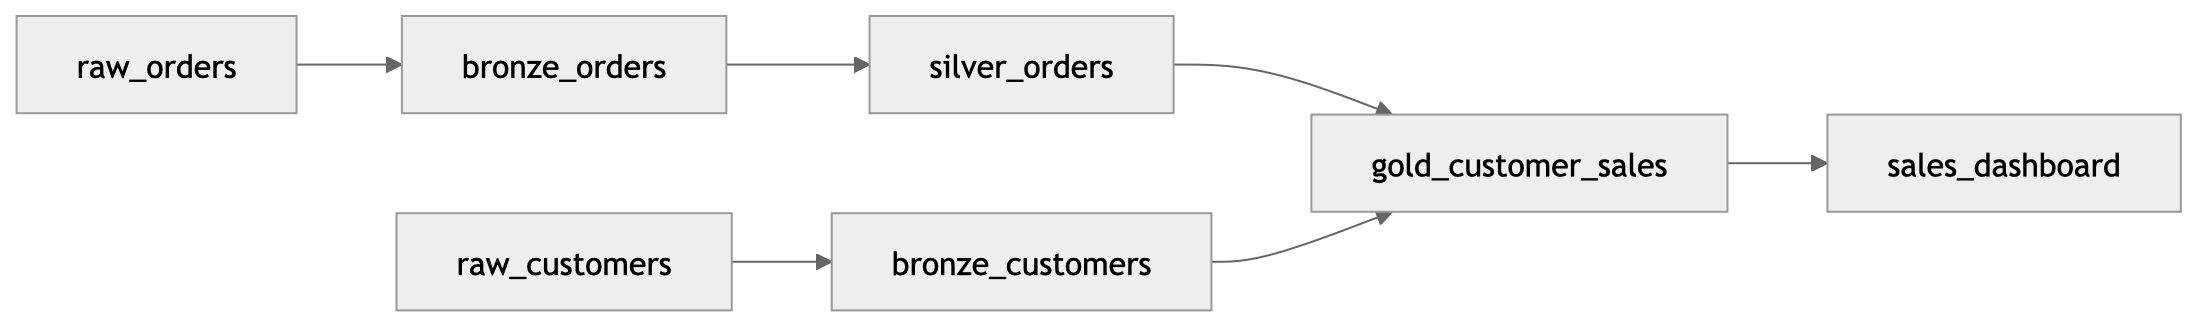

## 3.1 Table-level Lineage

แสดงความสัมพันธ์ระดับ table ว่า table ไหนมาจาก table ไหน ผ่าน transformation อะไร

In [ ]:
table_lineage_data = [
    ("raw_orders",    "bronze_orders",        "Cast order_date to date, add ingestion_time, source_system"),
    ("raw_customers", "bronze_customers",     "Add ingestion_time, source_system"),
    ("bronze_orders", "silver_orders",        "Drop null customer_id, deduplicate by order_id, calculate total_amount"),
    ("silver_orders",        "gold_customer_sales", "Join with bronze_customers, aggregate by customer"),
    ("bronze_customers",     "gold_customer_sales", "Provide customer_name and province via left join"),
]

table_lineage = spark.createDataFrame(
    table_lineage_data,
    ["source_table", "target_table", "transformation"]
)

print("=== Table-level Lineage ===")
table_lineage.show(truncate=False)

=== Table-level Lineage ===
+----------------+-------------------+----------------------------------------------------------------------+
|source_table    |target_table       |transformation                                                        |
+----------------+-------------------+----------------------------------------------------------------------+
|raw_orders      |bronze_orders      |Cast order_date to date, add ingestion_time, source_system            |
|raw_customers   |bronze_customers   |Add ingestion_time, source_system                                     |
|bronze_orders   |silver_orders      |Drop null customer_id, deduplicate by order_id, calculate total_amount|
|silver_orders   |gold_customer_sales|Join with bronze_customers, aggregate by customer                     |
|bronze_customers|gold_customer_sales|Provide customer_name and province via left join                      |
+----------------+-------------------+------------------------------------------------------

จากตารางนี้เราจะตอบได้ว่า target table แต่ละตัวมาจาก source table ไหน และผ่าน transformation อะไร  
เช่น `gold_customer_sales` มาจากทั้ง `silver_orders` และ `bronze_customers` เพราะต้อง join ข้อมูลยอดขายกับข้อมูลลูกค้าก่อน aggregate

## 3.2 Column-level Lineage

> column ปลายทางถูกสร้างจาก column ต้นทางไหน และผ่าน transformation อะไร


ค่อนข้างสำคัญมากเมื่อมีการ join, aggregate, calculate, alias หรือสร้าง derived column

In [ ]:
column_lineage_data = [
    # bronze_orders
    ("raw_orders.order_id",       "bronze_orders.order_id",      "Direct mapping"),
    ("raw_orders.customer_id",    "bronze_orders.customer_id",   "Direct mapping"),
    ("raw_orders.order_date",     "bronze_orders.order_date",    "Cast string → date (yyyy-MM-dd)"),
    ("raw_orders.product_name",   "bronze_orders.product_name",  "Direct mapping"),
    ("raw_orders.quantity",       "bronze_orders.quantity",      "Direct mapping"),
    ("raw_orders.unit_price",     "bronze_orders.unit_price",    "Cast → double"),
    ("(system)",                  "bronze_orders.ingestion_time", "current_timestamp()"),
    ("(literal)",                 "bronze_orders.source_system", "lit('orders_db')"),

    # silver_orders
    ("bronze_orders.order_id",    "silver_orders.order_id",      "After dropna + dropDuplicates"),
    ("bronze_orders.customer_id", "silver_orders.customer_id",   "After dropna(customer_id)"),
    ("bronze_orders.order_date",  "silver_orders.order_date",    "Direct mapping"),
    ("bronze_orders.quantity + bronze_orders.unit_price",
                                  "silver_orders.total_amount",   "quantity * unit_price"),

    # gold_customer_sales
    ("silver_orders.customer_id",    "gold_customer_sales.customer_id",    "Group by key"),
    ("bronze_customers.customer_name","gold_customer_sales.customer_name", "Left join by customer_id"),
    ("bronze_customers.province",     "gold_customer_sales.province",      "Left join by customer_id"),
    ("silver_orders.order_id",        "gold_customer_sales.total_orders",  "count(order_id)"),
    ("silver_orders.total_amount",    "gold_customer_sales.total_sales",   "sum(total_amount)"),
    ("silver_orders.total_amount",    "gold_customer_sales.avg_order_value", "avg(total_amount)"),
    ("silver_orders.order_date",      "gold_customer_sales.last_order_date", "max(order_date)"),
]

column_lineage = spark.createDataFrame(
    column_lineage_data,
    ["source_column", "target_column", "transformation_logic"]
)

print("=== Column-level Lineage ===")
column_lineage.show(truncate=False)

=== Column-level Lineage ===
+-------------------------------------------------+-----------------------------------+-------------------------------+
|source_column                                    |target_column                      |transformation_logic           |
+-------------------------------------------------+-----------------------------------+-------------------------------+
|raw_orders.order_id                              |bronze_orders.order_id             |Direct mapping                 |
|raw_orders.customer_id                           |bronze_orders.customer_id          |Direct mapping                 |
|raw_orders.order_date                            |bronze_orders.order_date           |Cast string → date (yyyy-MM-dd)|
|raw_orders.product_name                          |bronze_orders.product_name         |Direct mapping                 |
|raw_orders.quantity                              |bronze_orders.quantity             |Direct mapping                 |
|raw_orders


**Column-level lineage** ทำให้เห็นรายละเอียดมากกว่า table-level lineage  
เช่น `gold_customer_sales.total_sales` ไม่ได้มาจาก column เดียวโดยตรง แต่เกิดจาก `silver_orders.total_amount` ซึ่งก่อนหน้านั้นคำนวณจาก `quantity * unit_price`

### ตัวอย่างการใช้งาน

เช่น ถ้าอยากรู้ว่า `gold_customer_sales.total_sales` มาจากไหน:

In [ ]:
# ค้นหา lineage ของ column ที่สนใจ
target_col = "gold_customer_sales.total_sales"

print(f"Lineage ของ '{target_col}':")
column_lineage.filter(F.col("target_column") == target_col).show(truncate=False)

# ไล่ upstream ต่ออีกชั้น
print("Upstream ต่อ (silver_orders.total_amount):")
column_lineage.filter(F.col("target_column") == "silver_orders.total_amount").show(truncate=False)

Lineage ของ 'gold_customer_sales.total_sales':
+--------------------------+-------------------------------+--------------------+
|source_column             |target_column                  |transformation_logic|
+--------------------------+-------------------------------+--------------------+
|silver_orders.total_amount|gold_customer_sales.total_sales|sum(total_amount)   |
+--------------------------+-------------------------------+--------------------+

Upstream ต่อ (silver_orders.total_amount):
+-------------------------------------------------+--------------------------+---------------------+
|source_column                                    |target_column             |transformation_logic |
+-------------------------------------------------+--------------------------+---------------------+
|bronze_orders.quantity + bronze_orders.unit_price|silver_orders.total_amount|quantity * unit_price|
+-------------------------------------------------+--------------------------+-----------------

## 3.3 Impact Analysis

ถ้า asset หนึ่งมีปัญหาหรือจะเปลี่ยนแปลง → downstream อะไรบ้างที่ได้รับผลกระทบ?

ตัวอย่าง: `raw_orders.unit_price` มีข้อมูลผิด จะกระทบอะไรบ้าง?

In [ ]:
impact_data = [
    ("raw_orders.unit_price",          "bronze_orders.unit_price",          "Direct mapping — ผิดตั้งแต่ต้น"),
    ("bronze_orders.unit_price",       "silver_orders.total_amount",        "quantity * unit_price — ค่าผิดทันที"),
    ("silver_orders.total_amount",     "gold_customer_sales.total_sales",   "sum(total_amount) — ยอดรวมผิด"),
    ("silver_orders.total_amount",     "gold_customer_sales.avg_order_value","avg(total_amount) — avg ผิดด้วย"),
    ("gold_customer_sales.total_sales","sales_dashboard (downstream)",      "Dashboard แสดงตัวเลขผิดพลาด"),
]

impact_df = spark.createDataFrame(
    impact_data,
    ["changed_asset", "impacted_asset", "impact_reason"]
)

print("=== Impact Analysis: ถ้า raw_orders.unit_price ผิด ===")
impact_df.show(truncate=False)

=== Impact Analysis: ถ้า raw_orders.unit_price ผิด ===
+-------------------------------+-----------------------------------+-----------------------------------+
|changed_asset                  |impacted_asset                     |impact_reason                      |
+-------------------------------+-----------------------------------+-----------------------------------+
|raw_orders.unit_price          |bronze_orders.unit_price           |Direct mapping — ผิดตั้งแต่ต้น     |
|bronze_orders.unit_price       |silver_orders.total_amount         |quantity * unit_price — ค่าผิดทันที|
|silver_orders.total_amount     |gold_customer_sales.total_sales    |sum(total_amount) — ยอดรวมผิด      |
|silver_orders.total_amount     |gold_customer_sales.avg_order_value|avg(total_amount) — avg ผิดด้วย    |
|gold_customer_sales.total_sales|sales_dashboard (downstream)       |Dashboard แสดงตัวเลขผิดพลาด        |
+-------------------------------+-----------------------------------+----------------------------

แสดงว่า column ต้นทางเล็ก ๆ เช่น `raw_orders.unit_price` สามารถกระทบต่อ metric ปลายทางอย่าง `total_sales` และ dashboard ได้  
ดังนั้นก่อนเปลี่ยน schema, rename column หรือแก้ logic ใน upstream ควรตรวจ downstream dependencies ก่อนเสมอ

## 3.4 Root Cause Analysis Scenario

** สถานการณ์ ** Dashboard แสดง `total_sales` สูงผิดปกติ

วิธีไล่ย้อนจาก lineage

```
gold_customer_sales.total_sales  ← ตัวเลขผิดปกติ
         ↑
silver_orders.total_amount       ← มาจาก sum() → ตรวจ silver
         ↑
bronze_orders.quantity × unit_price  ← ตรวจ formula
         ↑
raw_orders.quantity + raw_orders.unit_price  ← ตรวจ source
```

** สาเหตุที่เป็นไปได้ **
- `unit_price` ใน raw_orders ผิด (เช่น ส่งมาเป็น cents แทน baht)
- `quantity` ถูก duplicate ก่อน silver layer
- join ใน gold layer เกิด duplicate row (many-to-many)
- aggregation logic มี bug

In [ ]:
# ทดลอง debug ทีละชั้น
print("Step 1: ตรวจ gold — ตัวเลขผิดปกติไหม?")
gold_customer_sales.select("customer_name", "total_orders", "total_sales").show()

print("Step 2: ตรวจ silver — total_amount เป็นเท่าไหร่?")
silver_orders.select("order_id", "customer_id", "quantity", "unit_price", "total_amount").show()

print("Step 3: ตรวจ raw — raw_orders มี row อะไรบ้าง?")
raw_orders.show()

Step 1: ตรวจ gold — ตัวเลขผิดปกติไหม?
+-------------+------------+-----------+
|customer_name|total_orders|total_sales|
+-------------+------------+-----------+
|        Alice|           2|    26500.0|
|      Charlie|           1|     7000.0|
|          Bob|           2|     3500.0|
+-------------+------------+-----------+

Step 2: ตรวจ silver — total_amount เป็นเท่าไหร่?
+--------+-----------+--------+----------+------------+
|order_id|customer_id|quantity|unit_price|total_amount|
+--------+-----------+--------+----------+------------+
|       1|        101|       1|   25000.0|     25000.0|
|       3|        101|       1|    1500.0|      1500.0|
|       2|        102|       2|     500.0|      1000.0|
|       5|        102|       1|    2500.0|      2500.0|
|       4|        103|       1|    7000.0|      7000.0|
+--------+-----------+--------+----------+------------+

Step 3: ตรวจ raw — raw_orders มี row อะไรบ้าง?
+--------+-----------+----------+------------+--------+----------+
|order

เมื่อ dashboard ผิด เราไม่ควรแก้ที่ dashboard ทันที แต่ควรไล่ย้อนผ่าน lineage
`dashboard → gold → silver → bronze → raw` ทำให้ช่วยหาจุดเริ่มต้นของปัญหาได้เร็วขึ้น

## 3.5 Data Catalog บันทึก metadata ของแต่ละ table

ใน production จะใช้ tools เช่น OpenMetadata, AWS Glue Data Catalog แต่ concept เดียวกันคือการเก็บ metadata ของ data assets

In [ ]:
catalog_data = [
    ("raw_orders",          "raw",    "orders_db",       "Data Engineering", "Raw order transactions จาก e-commerce system",    True),
    ("raw_customers",       "raw",    "crm_db",          "Data Engineering", "Raw customer records จาก CRM",                    True),
    ("bronze_orders",       "bronze", "pipeline",        "Data Engineering", "Orders พร้อม type casting และ ingestion metadata", False),
    ("bronze_customers",    "bronze", "pipeline",        "Data Engineering", "Customers พร้อม ingestion metadata",               False),
    ("silver_orders",       "silver", "pipeline",        "Data Engineering", "Orders ที่ clean แล้ว พร้อม total_amount",        False),
    ("gold_customer_sales", "gold",   "analytics_layer", "Analytics Team",   "Customer sales summary สำหรับ BI dashboard",      False),
]

data_catalog = spark.createDataFrame(
    catalog_data,
    ["table_name", "layer", "source", "owner", "description", "contains_pii"]
)

print("=== Data Catalog ===")
data_catalog.show(truncate=False)

=== Data Catalog ===
+-------------------+------+---------------+----------------+------------------------------------------------+------------+
|table_name         |layer |source         |owner           |description                                     |contains_pii|
+-------------------+------+---------------+----------------+------------------------------------------------+------------+
|raw_orders         |raw   |orders_db      |Data Engineering|Raw order transactions จาก e-commerce system    |true        |
|raw_customers      |raw   |crm_db         |Data Engineering|Raw customer records จาก CRM                    |true        |
|bronze_orders      |bronze|pipeline       |Data Engineering|Orders พร้อม type casting และ ingestion metadata|false       |
|bronze_customers   |bronze|pipeline       |Data Engineering|Customers พร้อม ingestion metadata              |false       |
|silver_orders      |silver|pipeline       |Data Engineering|Orders ที่ clean แล้ว พร้อม total_amount        |f

Data Catalog ช่วยให้รู้ว่าแต่ละ table คืออะไร อยู่ layer ไหน มาจาก source ใด ใครเป็น owner และมีข้อมูล sensitive/PII หรือไม่  
ใน AWS ecosystem แนวคิดนี้มักเกี่ยวข้องกับ **AWS Glue Data Catalog** สำหรับเก็บ metadata ของ database/table/schema และอาจต่อยอดไปยัง **Amazon DataZone** สำหรับ discovery, governance และ lineage visualization

---


**Key takeaway:**  
Data Lineage ไม่ได้ทำให้ pipeline ไม่พัง แต่ช่วยให้หาจุดที่พังได้เร็วและแม่นยำขึ้นมาก

ในงานจริง ถ้าใช้ AWS ภาพรวมอาจเป็นแบบนี้:

```text
S3 raw data
   ↓
AWS Glue Job / PySpark ETL
   ↓
S3 processed data หรือ Iceberg table
   ↓
Glue Data Catalog
   ↓
Athena / BI / Dashboard
   ↓
Amazon DataZone สำหรับ discovery, governance และ lineage
```


---
# Appendix

ส่วนนี้เป็น reference สำหรับ tools ที่ใช้ทำ Data Lineage ใน production จริง

## A.1 OpenLineage

OpenLineage เป็น **open standard** สำหรับ collect lineage metadata เกี่ยวกับ data pipeline

**Metadata หลักที่เก็บ:**
- **Dataset Metadata** — อธิบาย dataset: input/output, schema, column names, data types
- **Job Metadata** — อธิบาย process/งานที่ทำกับข้อมูล: job name, namespace
- **Run Metadata** — metadata ของการ run แต่ละครั้ง: run_id, start_time, end_time

**Lineage Event:**
- `START` — job run เริ่มแล้ว ระบุ input dataset
- `COMPLETE` — job run เสร็จแล้ว ระบุ output dataset พร้อม schema metadata

```python
# ตัวอย่าง OpenLineage event (simplified)
event = {
    "eventType": "COMPLETE",
    "job": {"namespace": "my_pipeline", "name": "bronze_to_silver"},
    "run": {"runId": "abc-123"},
    "inputs": [{"namespace": "s3://bucket", "name": "bronze_orders"}],
    "outputs": [{"namespace": "s3://bucket", "name": "silver_orders"}],
}
```

## A.2 OpenMetadata

OpenMetadata เป็น **Metadata Platform** สำหรับ track Data Lineage และรวม metadata จากหลายระบบในองค์กร

**เป้าหมายหลัก:** แก้ปัญหา Fragmented Metadata (metadata กระจัดกระจายหลายระบบ) โดยสร้าง Common Language ผ่าน JSON Schema

**ทุกอย่างถูกมองเป็น Entity:** Table, Database, Dashboard, Pipeline, User, Team

**Data Lineage ใน OpenMetadata = graph relationship **
```
Origin (ต้นทาง) → [Edge] → Destination (ปลายทาง)
```

**Features สำคัญ:**
- **Data Traceability** — trace ข้อมูลย้อนกลับไปยังต้นทาง
- **Data Quality Alerts** — แจ้งเตือน analyst เมื่อ table ต้นทางมีปัญหา
- **Description Propagation** — push description จาก column ต้นทางไปยัง downstream อัตโนมัติ

## A.3 Automated Lineage Approaches

| วิธี | ทำงานยังไง | ข้อดี | ข้อจำกัด |
|---|---|---|---|
| **Static Analysis** | Parse query/code แบบ static ไม่ต้องรัน | ใช้แรงน้อย | มองไม่เห็น data movement นอกระบบ |
| **Runtime Lineage** | เก็บ lineage ขณะ pipeline รันจริง | Update ตาม run จริง | อาจไม่รองรับ niche operations |
| **Data Tagging** | ทุก process อ่าน/เพิ่ม tag ขณะ process | Granular detail สูง | Expensive to implement |

**แนวทาง** Static Analysis ก่อน → Runtime Lineage → Data Tagging

## A.4 Tools ใน AWS Ecosystem


| Tool | บทบาท | เกี่ยวกับ Lineage อย่างไร |
|---|---|---|
| **Amazon S3** | Storage layer / Data Lake สำหรับเก็บ raw และ processed data | เป็นจุดต้นทางหรือปลายทางของ data files |
| **AWS Glue Job** | ETL job ที่มักเขียนด้วย Spark/PySpark | เป็น process ที่อ่าน input และสร้าง output |
| **AWS Glue Data Catalog** | Central metadata repository สำหรับ database/table/schema บน AWS | เก็บ metadata ของ table แต่ไม่ใช่ lineage visualization tool เต็มตัว |
| **Amazon Athena** | Query data บน S3 ด้วย SQL | เป็น consumer/query layer ที่ใช้ข้อมูลจาก catalog |
| **Amazon DataZone** | Data catalog, discovery, governance และ lineage platform | ใช้ดู data assets, ownership, governance และ lineage graph ในระดับองค์กร |
| **OpenLineage** | Open standard สำหรับ lineage events | ใช้เป็นมาตรฐานในการส่ง event ว่า job ไหนอ่าน/เขียน dataset ไหน |
| **dbt** | Transformation layer สำหรับ analytics engineering | มี lineage graph จาก dependency ระหว่าง models |
| **Apache Atlas / OpenMetadata / DataHub** | Metadata platform / governance tools | ใช้จัดการ catalog และ lineage ในองค์กรที่ต้องการ platform กลาง |

**สรุปแบบ**

- `S3` = ที่เก็บข้อมูล  
- `Glue Job` = ตัวแปลงข้อมูล  
- `Glue Data Catalog` = ตัวจด metadata ของ table/schema  
- `Athena` = ตัว query ด้วย SQL  
- `DataZone` = ตัวช่วยด้าน discovery, governance และ lineage  
- `OpenLineage` = รูปแบบมาตรฐานของ lineage event
